# BUPA Liver Disorders - TabNet (Google Colab)
Uses local Google Drive file.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.6 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.78098 | test_accuracy: 0.50725 |  0:00:01s
epoch 1  | loss: 0.70102 | test_accuracy: 0.52174 |  0:00:01s
epoch 2  | loss: 0.66107 | test_accuracy: 0.5942  |  0:00:01s
epoch 3  | loss: 0.66625 | test_accuracy: 0.5942  |  0:00:01s
epoch 4  | loss: 0.6497  | test_accuracy: 0.62319 |  0:00:01s
epoch 5  | loss: 0.62256 | test_accuracy: 0.62319 |  0:00:01s
epoch 6  | loss: 0.6131  | test_accuracy: 0.65217 |  0:00:01s
epoch 7  | loss: 0.6111  | test_accuracy: 0.62319 |  0:00:02s
epoch 8  | loss: 0.61011 | test_accuracy: 0.63768 |  0:00:02s
epoch 9  | loss: 0.59365 | test_accuracy: 0.62319 |  0:00:02s
epoch 10 | loss: 0.60967 | test_accuracy: 0.63768 |  0:00:02s
epoch 11 | loss: 0.58939 | test_accuracy: 0.6087  |  0:00:02s
epoch 12 | loss: 0.59342 | test_accuracy: 0.6087  |  0:00:03s
epoch 13 | loss: 0.57643 | test_accuracy: 0.6087  |  0:00:03s
epoch 14 | loss: 0.59195 | test_accuracy: 0.5942  |  0:00:03s
epoch 15 | loss: 0.58288 | test_accuracy: 0.63768 |  0:00:03s
epoch 16

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


              precision    recall  f1-score   support

           0       0.77      0.69      0.73        29
           1       0.79      0.85      0.82        40

    accuracy                           0.78        69
   macro avg       0.78      0.77      0.77        69
weighted avg       0.78      0.78      0.78        69

[[20  9]
 [ 6 34]]


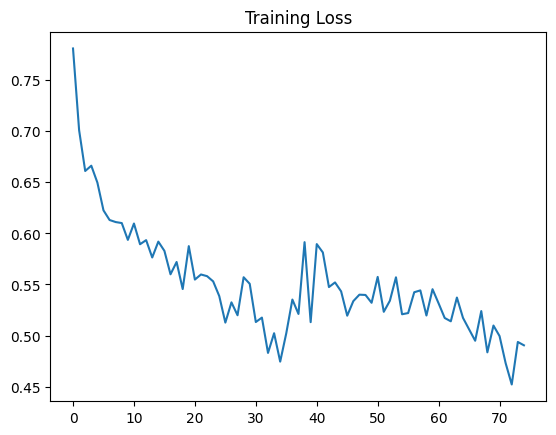

Successfully saved model at tabnet_bupa.zip
Model saved.


In [2]:
!pip -q install pytorch-tabnet scikit-learn matplotlib pandas

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from pytorch_tabnet.tab_model import TabNetClassifier
import matplotlib.pyplot as plt

DATA_PATH='/content/drive/MyDrive/Clinical Reasoning Agent/liver+disorders/bupa.data'  # <-- modify if needed

cols=['mcv','alkphos','sgpt','sgot','gammagt','drinks','selector']
df=pd.read_csv(DATA_PATH,names=cols)

X=df.drop(columns=['selector']).values
y=(df['selector'].astype(int)-1).values

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y)

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

clf=TabNetClassifier(seed=42,verbose=1)

clf.fit(
    X_train,y_train,
    eval_set=[(X_test,y_test)],
    eval_name=['test'],
    eval_metric=['accuracy'],
    max_epochs=100,
    patience=20,
    batch_size=64,
    virtual_batch_size=32
)

pred=clf.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred))
print(classification_report(y_test,pred))
print(confusion_matrix(y_test,pred))

plt.plot(clf.history['loss'])
plt.title('Training Loss')
plt.show()

clf.save_model('tabnet_bupa')
print('Model saved.')
